# Logistic Regression

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [5]:
pd.read_csv(r"C:\Users\HP\Downloads\CreditRisk59.csv")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,4.0,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,Y
977,LP002975,Male,Yes,0.0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,Y
978,LP002980,Male,No,0.0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,Y
979,LP002986,Male,Yes,0.0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,N


In [6]:
cr=pd.read_csv(r"C:\Users\HP\Downloads\CreditRisk59.csv")

In [7]:
cr.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [8]:
cr.isnull().sum()[cr.isnull().sum()>0]

Gender              24
Married              3
Dependents          25
Self_Employed       55
LoanAmount          27
Loan_Amount_Term    20
Credit_History      79
dtype: int64

In [9]:
cr.Gender.fillna('Male', inplace = True)
cr. Married. fillna('Yes', inplace = True)
cr. Dependents. fillna(0, inplace = True)
cr. LoanAmount.fillna(cr.LoanAmount.mean(), inplace = True)
cr. Loan_Amount_Term.fillna(cr.Loan_Amount_Term.mean(), inplace = True)
cr. Credit_History. fillna(0, inplace = True)
cr.Self_Employed.fillna('No', inplace= True)

In [10]:
cr1=cr

In [11]:
cr=cr.drop(['Loan_ID'],axis=1)
cr

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,142.51153,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.00000,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.00000,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.00000,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.00000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
976,Male,Yes,4.0,Not Graduate,Yes,4009,1777.0,113.00000,360.0,1.0,Urban,Y
977,Male,Yes,0.0,Graduate,No,4158,709.0,115.00000,360.0,1.0,Urban,Y
978,Male,No,0.0,Graduate,No,3250,1993.0,126.00000,360.0,0.0,Semiurban,Y
979,Male,Yes,0.0,Graduate,No,5000,2393.0,158.00000,360.0,1.0,Rural,N


In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [13]:
cr[cr.select_dtypes(include='object').columns]


,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,Graduate,No,Urban,Y
1,Male,Yes,Graduate,No,Rural,N
2,Male,Yes,Graduate,Yes,Urban,Y
3,Male,Yes,Not Graduate,No,Urban,Y
4,Male,No,Graduate,No,Urban,Y
...,...,...,...,...,...,...
976,Male,Yes,Not Graduate,Yes,Urban,Y
977,Male,Yes,Graduate,No,Urban,Y
978,Male,No,Graduate,No,Semiurban,Y
979,Male,Yes,Graduate,No,Rural,N


In [14]:
cr[cr.select_dtypes(include='object').columns] = cr[cr.select_dtypes(include='object').columns].apply(le.fit_transform)

In [15]:
cr

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,142.51153,360.0,1.0,2,1
1,1,1,1.0,0,0,4583,1508.0,128.00000,360.0,1.0,0,0
2,1,1,0.0,0,1,3000,0.0,66.00000,360.0,1.0,2,1
3,1,1,0.0,1,0,2583,2358.0,120.00000,360.0,1.0,2,1
4,1,0,0.0,0,0,6000,0.0,141.00000,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
976,1,1,4.0,1,1,4009,1777.0,113.00000,360.0,1.0,2,1
977,1,1,0.0,0,0,4158,709.0,115.00000,360.0,1.0,2,1
978,1,0,0.0,0,0,3250,1993.0,126.00000,360.0,0.0,1,1
979,1,1,0.0,0,0,5000,2393.0,158.00000,360.0,1.0,0,0


In [16]:
cr1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,142.51153,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.00000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.00000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.00000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.00000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,4.0,Not Graduate,Yes,4009,1777.0,113.00000,360.0,1.0,Urban,Y
977,LP002975,Male,Yes,0.0,Graduate,No,4158,709.0,115.00000,360.0,1.0,Urban,Y
978,LP002980,Male,No,0.0,Graduate,No,3250,1993.0,126.00000,360.0,0.0,Semiurban,Y
979,LP002986,Male,Yes,0.0,Graduate,No,5000,2393.0,158.00000,360.0,1.0,Rural,N


In [17]:
from sklearn.model_selection import train_test_split
cr_train,cr_test=train_test_split(cr,test_size=.2)

In [18]:
# over sampling
df1=cr_train[cr_train.Loan_Status==0]
cr_train=pd.concat([cr_train,df1,df1])
cr_train.shape

(1212, 12)

In [19]:
cr_train .Loan_Status.value_counts()

Loan_Status
0    642
1    570
Name: count, dtype: int64

In [20]:
cr_train_x=cr_train.iloc[:,0:-1]
cr_train_y=cr_train.iloc[:,-1]

cr_test_x=cr_test.iloc[:,0:-1]
cr_test_y=cr_test.iloc[:,-1]

In [21]:
cr_test_x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
764,1,0,0.0,0,0,3071,4309.0,180.0,360.0,1.0,2
174,1,1,0.0,1,1,4344,736.0,87.0,360.0,1.0,1
407,0,0,0.0,1,0,2213,0.0,66.0,360.0,1.0,0
823,1,0,1.0,1,0,2038,4027.0,100.0,360.0,1.0,0
331,1,0,0.0,0,0,2935,0.0,98.0,360.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
611,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2
810,1,1,1.0,0,0,4796,0.0,114.0,360.0,0.0,1
711,1,1,0.0,0,0,3500,3250.0,140.0,360.0,1.0,1
32,1,0,1.0,0,1,4692,0.0,106.0,360.0,1.0,0


In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
logreg=LogisticRegression()
logreg.fit(cr_train_x,cr_train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
pred_train=logreg.predict(cr_train_x)
pred_test=logreg.predict(cr_test_x)

In [25]:
from sklearn.metrics import confusion_matrix

In [26]:
mat_test=confusion_matrix(cr_test_y,pred_test)
mat_test

array([[ 36,  19],
       [ 14, 128]])

In [27]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [28]:
16/(16+29)*100

35.55555555555556

In [29]:
accuracy_score(cr_test_y,pred_test)

0.8324873096446701

In [31]:
recall_score(cr_test_y,pred_test)

0.9014084507042254

In [32]:
precision_score(cr_test_y,pred_test)

0.8707482993197279

In [33]:
f1_score(cr_test_y,pred_test)

0.8858131487889274

In [34]:
# recall / TPR
mat_test.diagonal().sum()/ mat_test.sum()

np.float64(0.8324873096446701)

In [35]:
mat_test1=pd.DataFrame(mat_test)
mat_test1.columns=['rej','app']

In [36]:
mat_test1.index=['rej','app']

In [37]:
mat_test1

,rej,app
rej,36,19
app,14,128


In [38]:
pred_prob_test=logreg.predict_proba(cr_test_x)
len(pred_prob_test)

197

In [39]:
from sklearn.metrics import roc_auc_score,roc_curve

In [40]:
roc_auc_score(cr_test_y,pred_prob_test[:,1]) # area under the curve the value

0.8208706786171576

In [41]:
fpr,tpr,thre  =roc_curve(cr_test_y,pred_prob_test[:,1])

In [42]:
import matplotlib.pyplot as plt

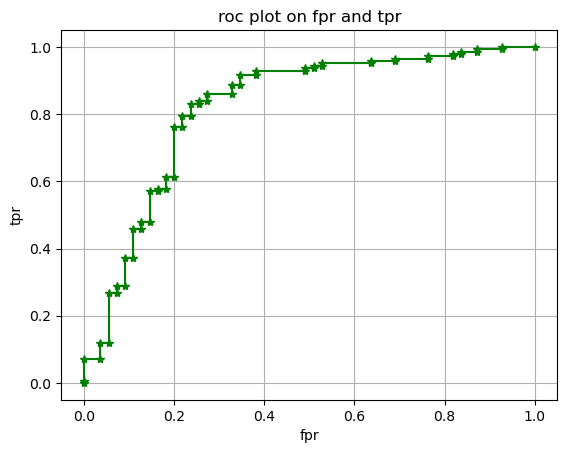

In [43]:
plt.plot(fpr,tpr,marker='*' , color='green')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('roc plot on fpr and tpr')
plt.grid()